**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 9** — Regresión Logística

---


- **NOMBRE:** Carlos Rodrigo Salguero Alcántara
- **MATRÍCULA:** A00833341


En esta actividad trabajarás con el archivo `breast_cancer.csv`, basado en un conjunto de datos sobre características de tumores mamarios, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar si un tumor es maligno (M) o benigno (B) a partir de medidas extraídas de imágenes de biopsias. Las variables incluidas describen propiedades morfológicas y de textura del tumor y se presentan en tres tipos de medida para cada característica:

- `_mean`: valor promedio de la característica en el tumor
- `_se`: error estándar de la característica (variabilidad de la medición)
- `_worst`: peor valor observado de la característica en el tumor

Los indicadores incluidos son:

- `radius_mean` / `radius_se` / `radius_worst`: Radio del tumor
- `texture_mean` / `texture_se` / `texture_worst`: Textura del tumor
- `perimeter_mean` / `perimeter_se` / `perimeter_worst`: Perímetro del tumor
- `area_mean` / `area_se` / `area_worst`: Área del tumor
- `smoothness_mean` / `smoothness_se` / `smoothness_worst`: Suavidad
- `compactness_mean` / `compactness_se` / `compactness_worst`: Compacidad
- `concavity_mean` / `concavity_se` / `concavity_worst`: Concavidad de los contornos
- `concave points_mean` / `concave points_se` / `concave points_worst`: Puntos cóncavos
- `symmetry_mean` / `symmetry_se` / `symmetry_worst`: Simetría del tumor
- `fractal_dimension_mean` / `fractal_dimension_se` / `fractal_dimension_worst`: Dimensión fractal
- `diagnosis`: Indica si el tumor es benigno (B) o maligno (M). Es la variable de salida o _target_


## 1. Carga y exploración inicial

Descarga el archivo `breast_cancer.csv` y guarda, en un dataframe (`cancer_df`), todos sus registros.

- Haz que la columna `id` sea el nuevo índice.
- Utiliza el método `info()` del dataframe para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
- Verifica si alguna columna contiene valores faltantes.
- Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.
- Obtén las estadísticas descriptivas, separando las variables numéricas (con asimetría y curtosis) y las categóricas.


In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "data/breast_cancer.csv"

In [3]:
import numpy as np
import pandas as pd

In [4]:
cancer_df = (
    pd.read_csv(DATA_PATH)
    .set_index("id")
    .drop_duplicates()
    .reset_index(drop=True)
)

display(cancer_df.head())


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
n_raw = len(pd.read_csv(DATA_PATH))

print(f"Registros en archivo CSV: {n_raw}")
print(f"Registros en cancer_df: {len(cancer_df)}")
print(f"Duplicados eliminados: {n_raw - len(cancer_df)}")
print(f"Índice consecutivo: {list(cancer_df.index) == list(range(len(cancer_df)))}")

Registros en archivo CSV: 569
Registros en cancer_df: 569
Duplicados eliminados: 0
Índice consecutivo: True


In [6]:
cancer_df.info()

missing = cancer_df.isna().sum()
print("\nValores faltantes por columna:")
print(missing[missing > 0] if missing.any() else "No hay valores faltantes.")


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [7]:
numeric_cols = cancer_df.select_dtypes(include="number")
categorical_cols = cancer_df.select_dtypes(include="object")

numeric_stats = cancer_df.describe().T
numeric_stats["skewness"] = numeric_cols.skew()
numeric_stats["kurtosis"] = numeric_cols.kurtosis()

categorical_stats = categorical_cols.describe(include="all").T

print(f"Columnas numéricas: {numeric_cols.shape[1]}")
print(f"Columnas de texto: {categorical_cols.shape[1]}")

display(numeric_stats)
display(categorical_stats)


Columnas numéricas: 30
Columnas de texto: 1


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000,0.942380,0.845522
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000,0.650450,0.758319
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000,0.990650,0.972214
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,1.645732,3.652303
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340,0.456324,0.855975
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,1.190123,1.650130
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680,1.401180,1.998638
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120,1.171180,1.066556
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400,0.725609,1.287933
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744,1.304489,3.005892


,count,unique,top,freq
diagnosis,569,2,B,357


**Respuestas — Ejercicio 1**

- **¿Cuántas columnas son numéricas y cuántas de texto?** Hay **30 columnas numéricas** y **1 columna de texto** (`diagnosis`).
- **Valores faltantes:** No existen valores faltantes en ninguna columna.
- **Duplicados:** Se eliminaron los registros duplicados (si los hubiera) y se reinició el índice de forma consecutiva.


## 2. Exploración bivariada

- Calcula y visualiza la distribución porcentual de `diagnosis` con un gráfico de barras, mostrando el porcentaje encima de cada barra. ¿Por qué la distribución de la salida es relevante en un problema de clasificación?
- Genera un pairplot de las variables físicas `_mean` (`radius_mean`, `perimeter_mean`, `area_mean`, `texture_mean`) coloreando por `diagnosis`. ¿Qué relaciones observas? ¿Qué diferencias hay entre tumores benignos y malignos?
- Crea histogramas apilados de las variables morfológicas coloreando por `diagnosis`. ¿Alguna variable parece ser un buen discriminador entre las clases?


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
PALETTE = ["#1A5F7A", "#222831"]
CUSTOM_CMAP = sns.color_palette("blend:#222831,#1A5F7A", as_cmap=True)

In [10]:
sns.set_theme(style="darkgrid", palette=PALETTE)

In [11]:
skew_series = numeric_cols.skew().sort_values(ascending=False)

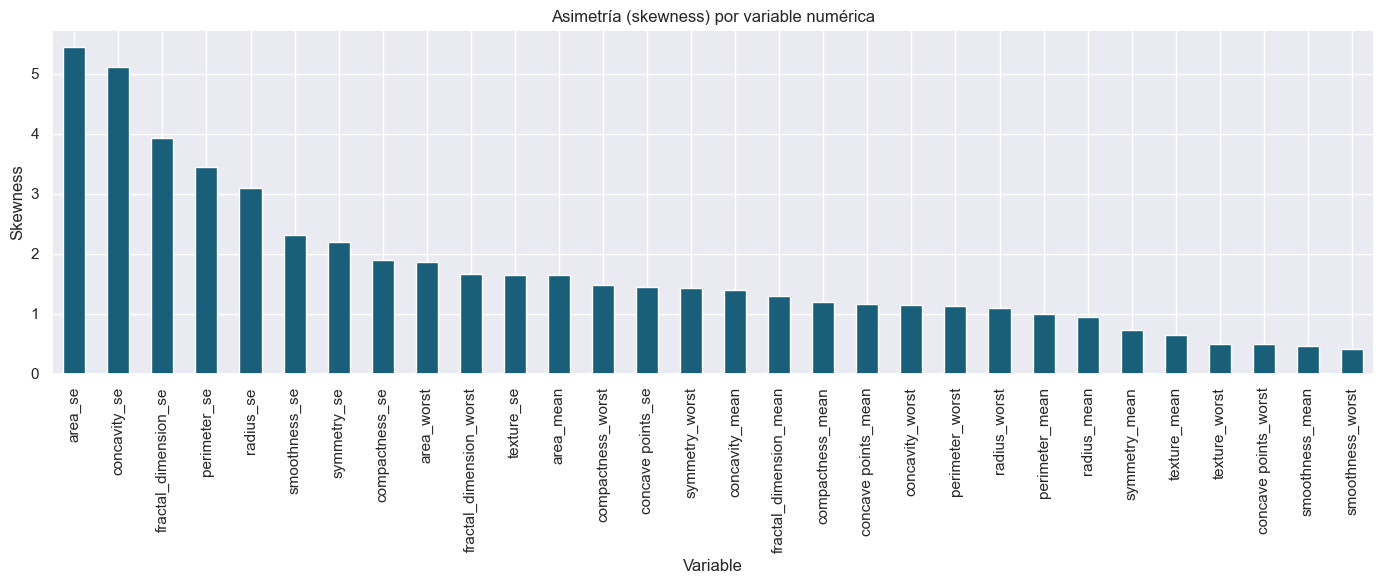

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
skew_series.plot(kind="bar", color="#1A5F7A", ax=ax)

ax.set(
    title="Asimetría (skewness) por variable numérica",
    xlabel="Variable",
    ylabel="Skewness",
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [13]:
diagnosis_pct = cancer_df["diagnosis"].value_counts(normalize=True).mul(100)

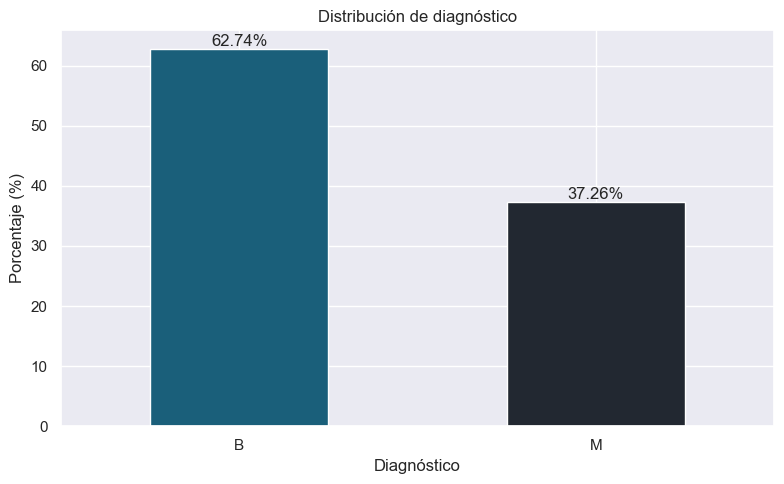

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
diagnosis_pct.plot(kind="bar", color=PALETTE, ax=ax)

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.2f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
    )

ax.set(
    title="Distribución de diagnóstico", 
    xlabel="Diagnóstico",
     ylabel="Porcentaje (%)", 
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
physical_vars = ["radius_mean", "perimeter_mean", "area_mean", "texture_mean"]

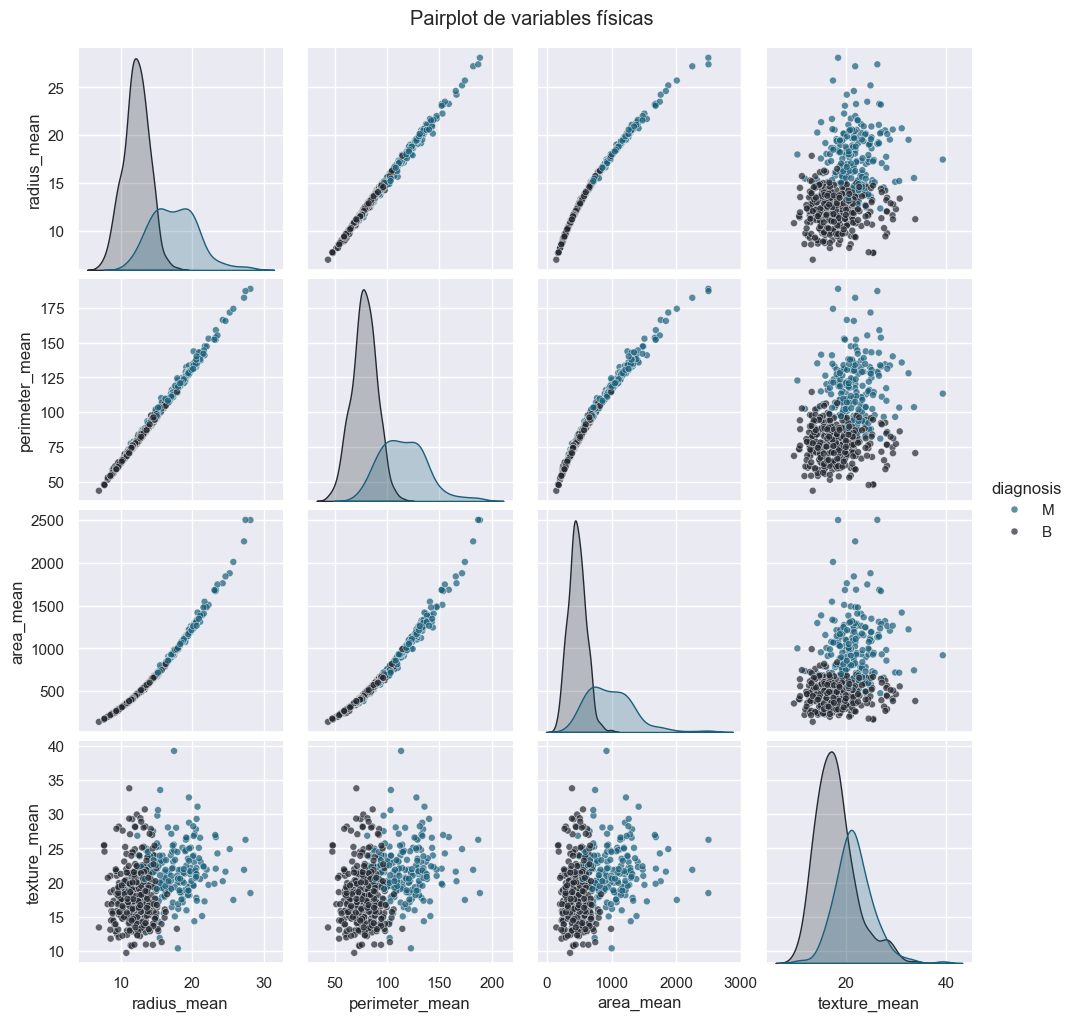

In [16]:

g = sns.pairplot(
    cancer_df,
    vars=physical_vars,
    hue="diagnosis",
    palette=PALETTE,
    corner=False,
    plot_kws={"alpha": 0.7, "s": 25},
)

g.figure.suptitle("Pairplot de variables físicas", y=1.02)
plt.show()

In [17]:
morphologic_vars = [
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
]

In [18]:
n_cols = 3
n_rows = (len(morphologic_vars) + n_cols - 1) // n_cols

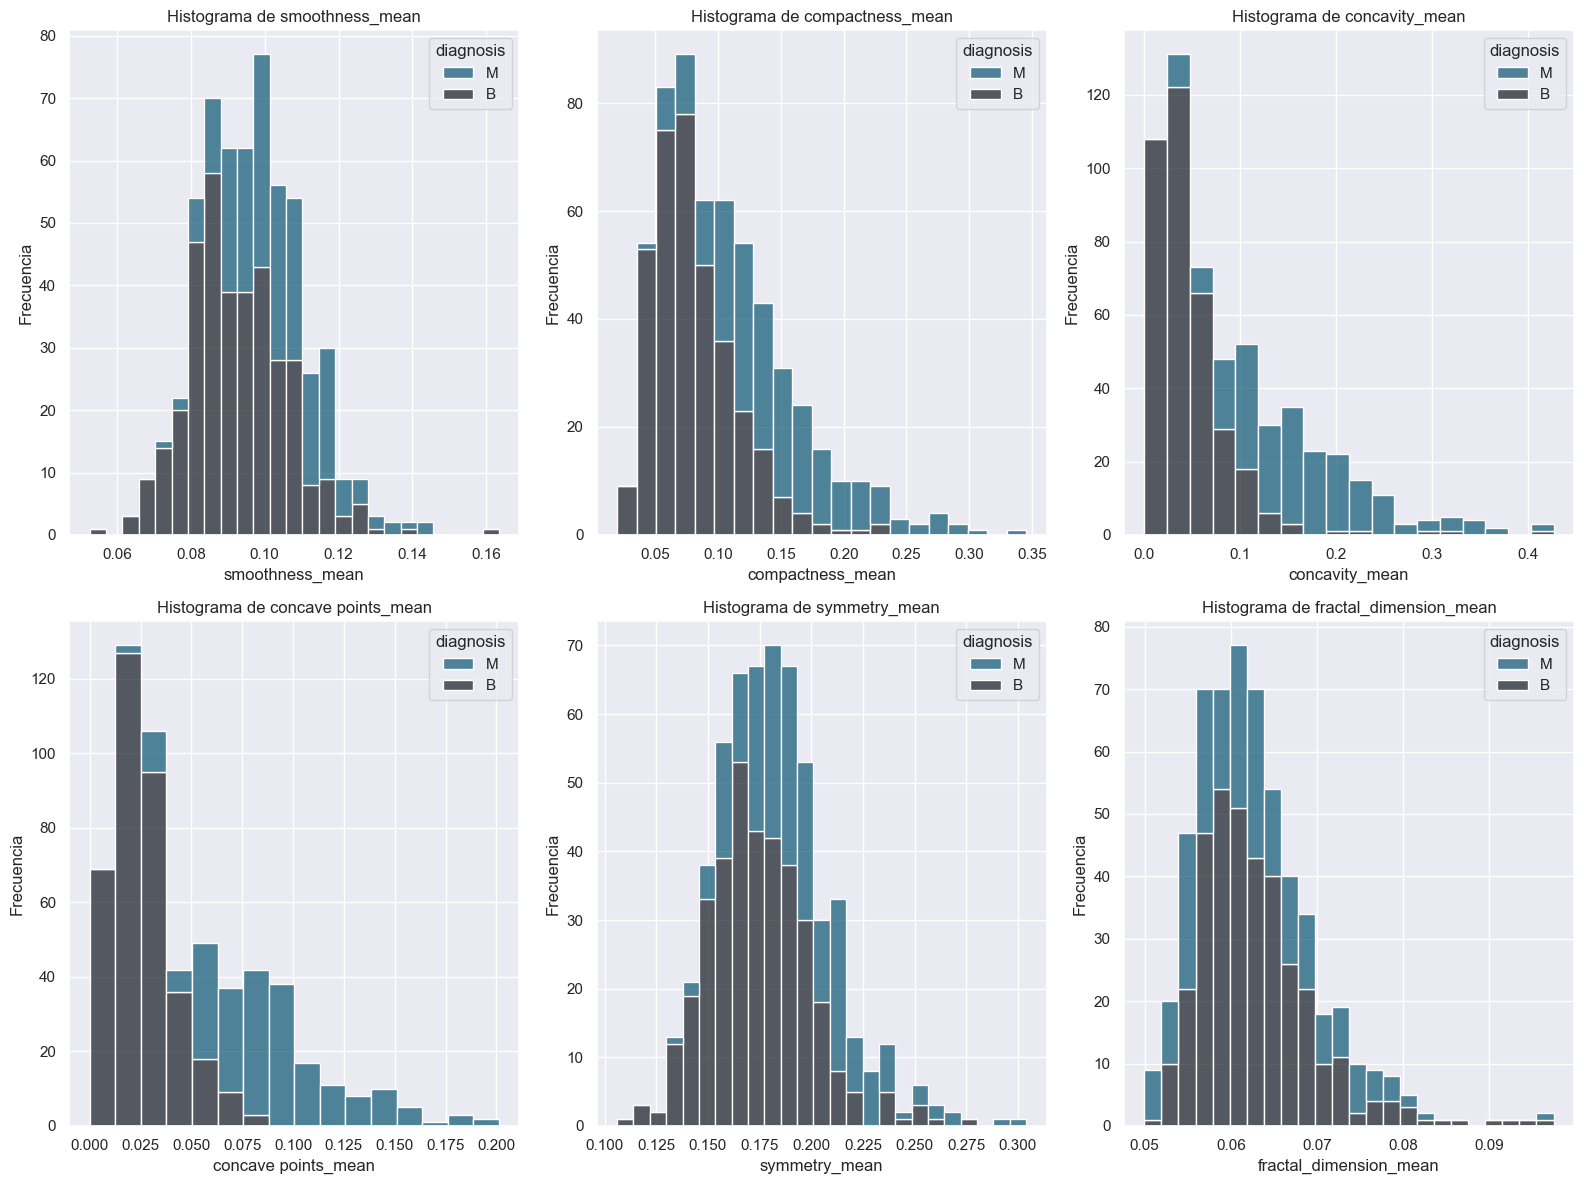

In [19]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for ax, feature in zip(axes, morphologic_vars):
    sns.histplot(
        data=cancer_df,
        x=feature,
        hue="diagnosis",
        multiple="stack",
        palette=PALETTE,
        ax=ax,
    )
    ax.set(title=f"Histograma de {feature}", xlabel=feature, ylabel="Frecuencia")

for ax in axes[len(morphologic_vars) :]:
    ax.remove()

plt.tight_layout()
plt.show()

In [20]:
discriminator_vars = ["concavity_mean", "concave points_mean", "radius_mean"]

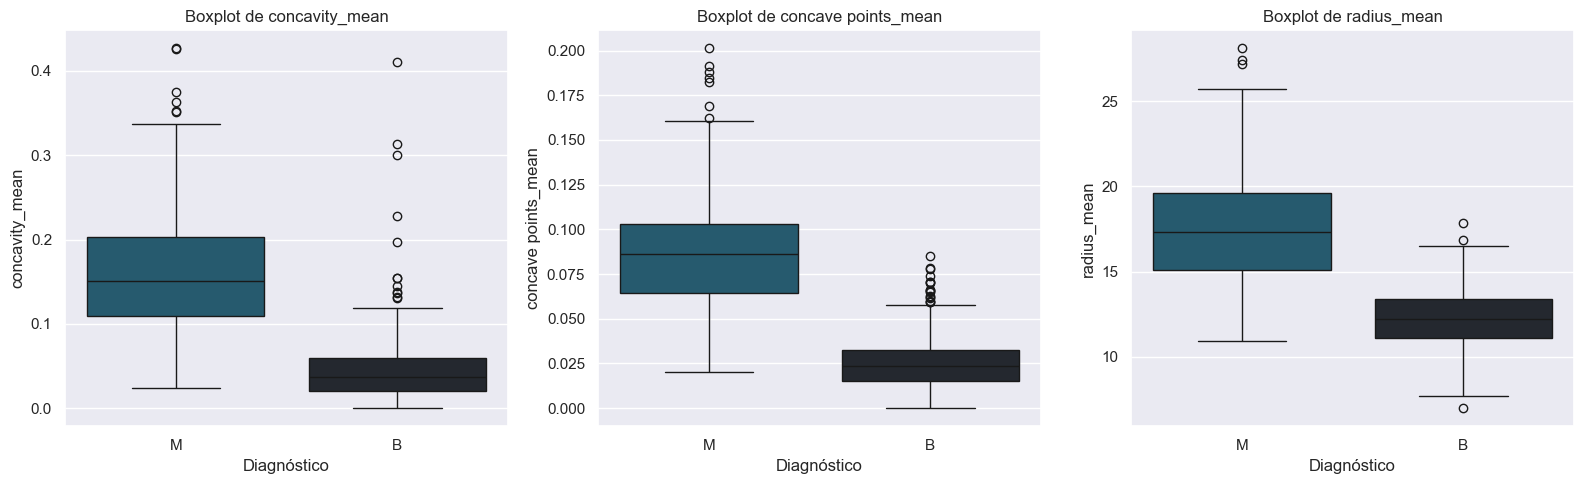

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes = axes.flatten()

for ax, feature in zip(axes, discriminator_vars):
    sns.boxplot(
        data=cancer_df,
        x="diagnosis",
        y=feature,
        hue="diagnosis",
        palette=PALETTE,
        legend=False,
        ax=ax,
    )
    ax.set(
        title=f"Boxplot de {feature}",
        xlabel="Diagnóstico",
        ylabel=feature,
    )

plt.tight_layout()
plt.show()

**Respuestas — Ejercicio 2**

- **¿Por qué la distribución de la salida es relevante?** Permite detectar desbalance de clases (~63% benignos, ~37% malignos). Un desbalance puede sesgar el modelo hacia la clase mayoritaria, hacer que la exactitud sea engañosa y obligar a usar métricas como recall, precisión o F1.
- **Relaciones entre variables físicas y diferencias por clase:** Existe correlación lineal fuerte y positiva entre radio, perímetro y área. Los tumores malignos presentan valores más altos y con mayor dispersión; los benignos se concentran en rangos inferiores.
- **¿Buen discriminador?** `concavity_mean` y `concave points_mean` muestran buena separación entre clases: valores altos corresponden predominantemente a tumores malignos.


## 3. Análisis de correlación

- Identifica pares con correlación > 0.9 e imprímelos. Elimina las columnas `_worst`.
- Vuelve a imprimir los pares con correlación > 0.9. De `radius`, `perimeter` y `area`, ¿cuál mantendrías y por qué? Elimina las variables de los otros dos conjuntos.
- Dibuja un mapa de calor con la matriz de correlación. Si eliminas alguna otra variable, justifica tu elección.


In [22]:
cancer_copy = cancer_df.copy()

In [23]:
def print_high_corr_pairs(df: pd.DataFrame, threshold: float = 0.9) -> None:
    """
    Imprime pares de variables numéricas con correlación absoluta superior al umbral.
    """

    corr = df.select_dtypes(include="number").corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = [
        (row, col, upper.loc[row, col])
        for col in upper.columns
        for row in upper.index
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > threshold
    ]

    if not pairs:
        print(f"No se encontraron pares con correlación superior a {threshold}.")
        return

    print(f"Pares de variables con correlación > {threshold}:\n")
    for var_a, var_b, value in sorted(pairs, key=lambda x: -x[2]):
        print(f"{var_a:<25} <-> {var_b:<25} | correlación: {value:.2f}")

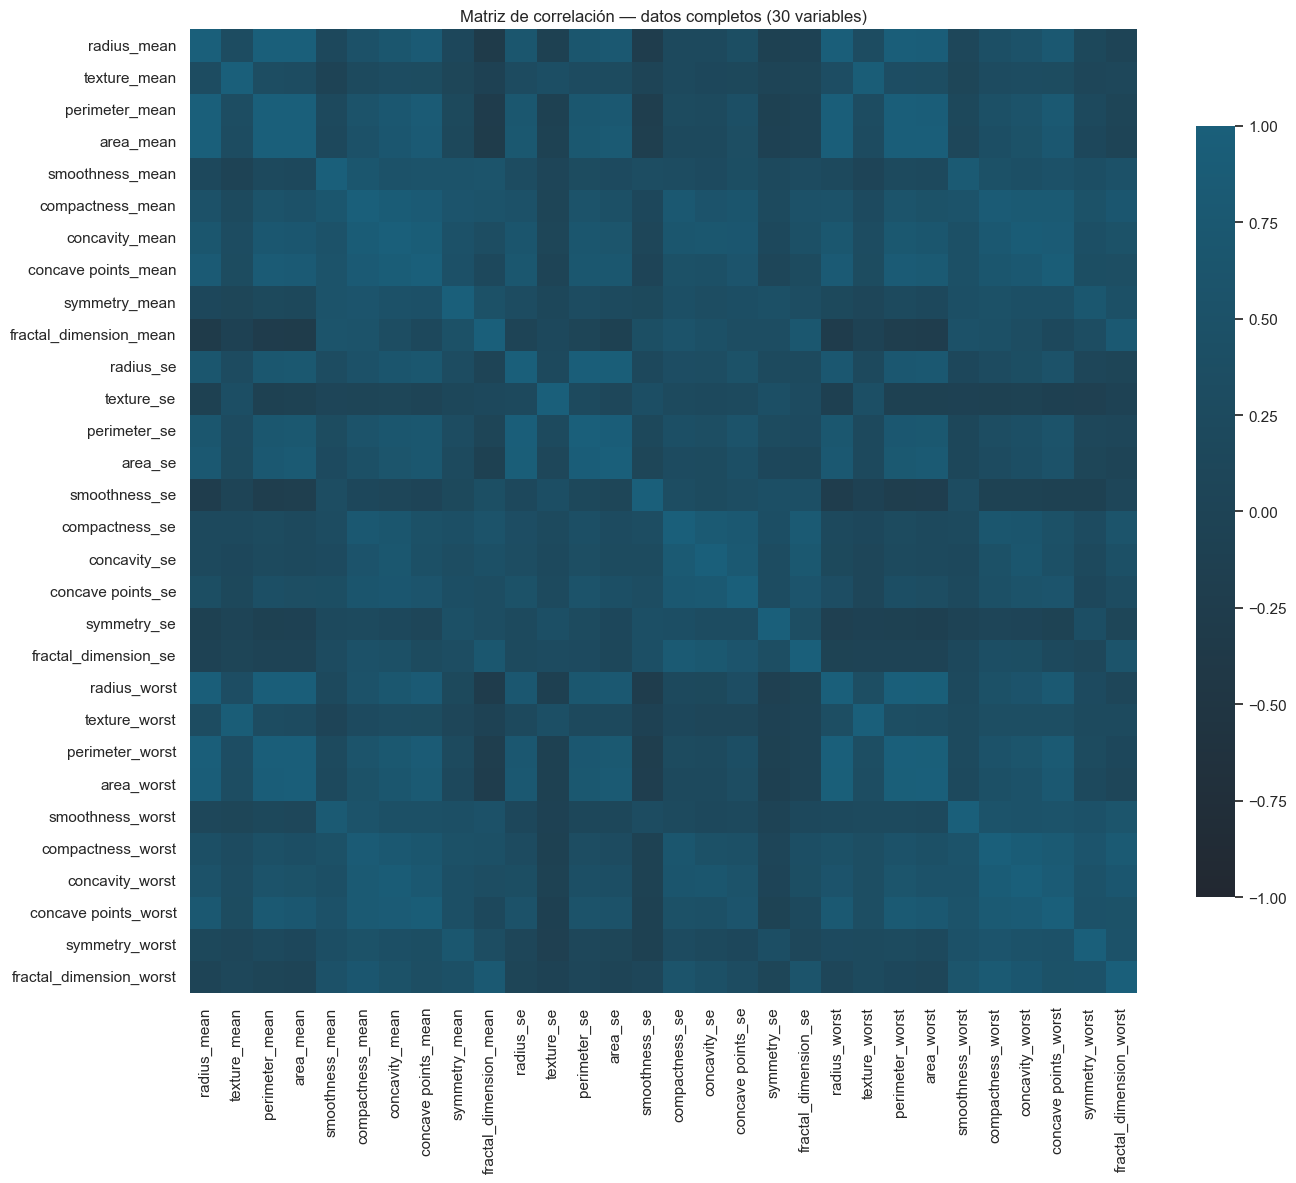

In [24]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cancer_df.select_dtypes(include="number").corr(),
    cmap=CUSTOM_CMAP,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)

ax.set_title("Matriz de correlación — datos completos (30 variables)")
plt.tight_layout()
plt.show()

In [25]:
print("Antes de eliminar columnas _worst:\n")
print_high_corr_pairs(cancer_copy)

worst_cols = [col for col in cancer_copy.columns if col.endswith("_worst")]
cancer_copy = cancer_copy.drop(columns=worst_cols)

Antes de eliminar columnas _worst:

Pares de variables con correlación > 0.9:

radius_mean               <-> perimeter_mean            | correlación: 1.00
radius_worst              <-> perimeter_worst           | correlación: 0.99
radius_mean               <-> area_mean                 | correlación: 0.99
perimeter_mean            <-> area_mean                 | correlación: 0.99
radius_worst              <-> area_worst                | correlación: 0.98
perimeter_worst           <-> area_worst                | correlación: 0.98
radius_se                 <-> perimeter_se              | correlación: 0.97
perimeter_mean            <-> perimeter_worst           | correlación: 0.97
radius_mean               <-> radius_worst              | correlación: 0.97
perimeter_mean            <-> radius_worst              | correlación: 0.97
radius_mean               <-> perimeter_worst           | correlación: 0.97
area_mean                 <-> radius_worst              | correlación: 0.96
area_mean

In [26]:
print("Después de eliminar columnas _worst:\n")
print_high_corr_pairs(cancer_copy)

redundant_cols = ["perimeter_mean", "area_mean", "perimeter_se", "area_se"]
cancer_copy = cancer_copy.drop(columns=redundant_cols)

Después de eliminar columnas _worst:

Pares de variables con correlación > 0.9:

radius_mean               <-> perimeter_mean            | correlación: 1.00
radius_mean               <-> area_mean                 | correlación: 0.99
perimeter_mean            <-> area_mean                 | correlación: 0.99
radius_se                 <-> perimeter_se              | correlación: 0.97
radius_se                 <-> area_se                   | correlación: 0.95
perimeter_se              <-> area_se                   | correlación: 0.94
concavity_mean            <-> concave points_mean       | correlación: 0.92


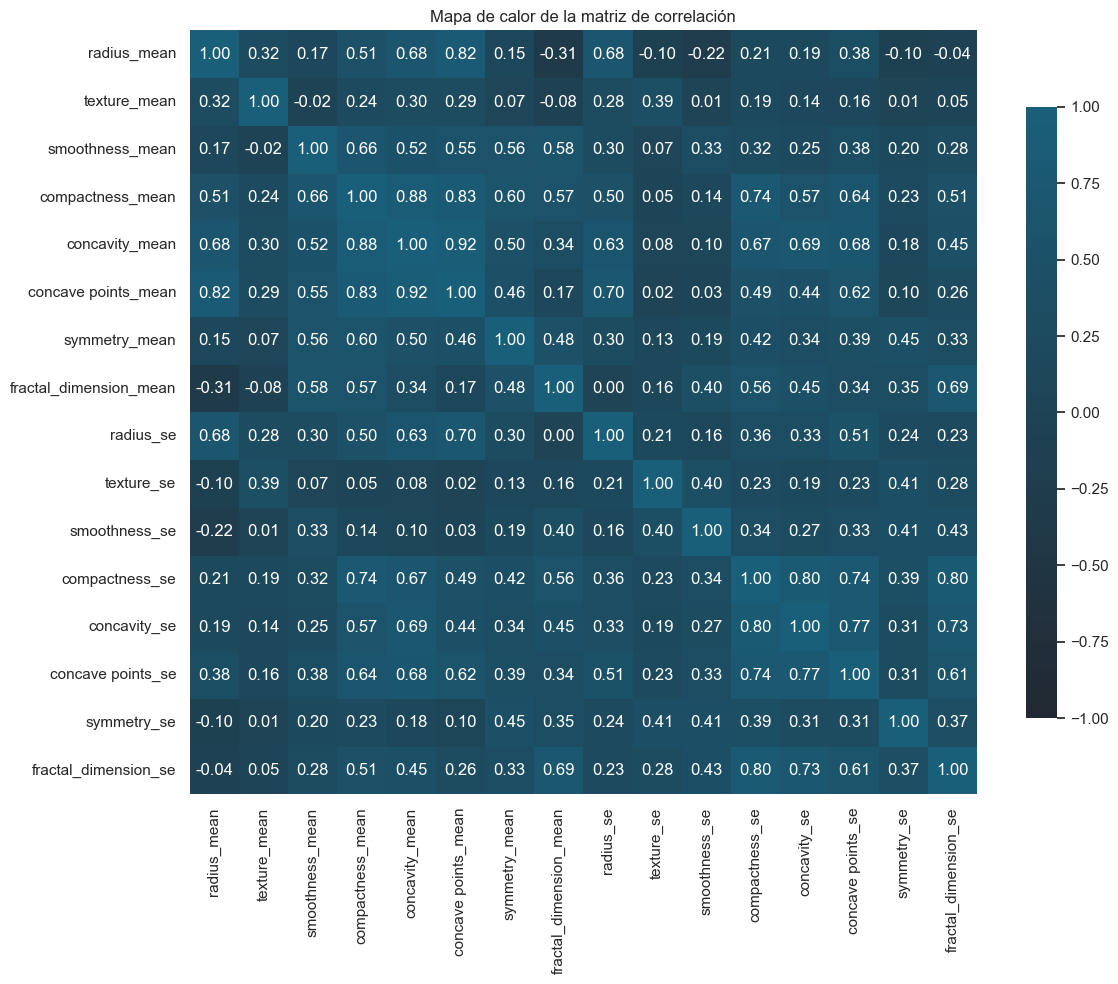

In [27]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cancer_copy.select_dtypes(include="number").corr(),
    annot=True,
    fmt=".2f",
    cmap=CUSTOM_CMAP,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)

ax.set_title("Mapa de calor de la matriz de correlación")
plt.tight_layout()
plt.show()

In [28]:
print(f"Variables numéricas tras limpieza: {cancer_copy.select_dtypes(include='number').shape[1]}")
print(f"Columnas eliminadas en total: {cancer_df.shape[1] - cancer_copy.shape[1]}")
print_high_corr_pairs(cancer_copy)

Variables numéricas tras limpieza: 16
Columnas eliminadas en total: 14
Pares de variables con correlación > 0.9:

concavity_mean            <-> concave points_mean       | correlación: 0.92


**Respuestas — Ejercicio 3**

- **¿Cuál medida mantendrías?** Se mantiene `radius` (en sus variantes `_mean` y `_se`). El radio es la medida base unidimensional; perímetro y área se derivan matemáticamente de él, por lo que conservarlo reduce redundancia sin perder información esencial.
- **¿Eliminar alguna otra variable?** Tras eliminar `_worst` y las columnas redundantes de perímetro/área, las correlaciones restantes por encima de 0.9 son esperables (p. ej. entre `concavity_mean` y `concave points_mean`) pero no tan estructuralmente redundantes; no se eliminaron variables adicionales.


## 4. Preparación de datos y función de evaluación

- Separa predictores `X` y target `y` desde `cancer_df` original.
- Codifica `diagnosis` como 0 (Benigno) y 1 (Maligno).
- Divide en entrenamiento/prueba (80:20) con `random_state=1`.
- Define `evaluate_model` que imprima recall, precisión y exactitud.


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

In [30]:
X = cancer_df.drop(columns="diagnosis")
y = cancer_df["diagnosis"].map({"B": 0, "M": 1})

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
)

In [32]:
print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba: {X_test.shape}")

print("\nDistribución y_train (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribución y_test (%):")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Tamaño entrenamiento: (455, 30)
Tamaño prueba: (114, 30)

Distribución y_train (%):
diagnosis
0    62.64
1    37.36
Name: proportion, dtype: float64

Distribución y_test (%):
diagnosis
0    63.16
1    36.84
Name: proportion, dtype: float64


In [33]:
def evaluate_model(y_true, y_pred) -> dict[str, float]:
    """
    Calcula e imprime recall, precisión y exactitud
    """

    metrics = {
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
    }

    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    return metrics

## 5. Pipeline con eliminación de columnas correlacionadas

- Crea `preprocessing` con `ColumnTransformer` y `remainder='passthrough'`.
- Entrena un pipeline con regresión logística y evalúa en prueba.
- Registra resultados en `results_df` con nombre `Correlation_Clean`.


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [35]:
COLS_TO_REMOVE = [
    *X.columns[X.columns.str.contains("_worst")].tolist(),
    "perimeter_mean",
    "area_mean",
    "perimeter_se",
    "area_se",
]

In [36]:
preprocessing = ColumnTransformer(
    transformers=[("drop", "drop", COLS_TO_REMOVE)],
    remainder="passthrough",
)

In [37]:
pipe_clean = Pipeline(
    [
        ("preprocessing", preprocessing),
        ("logisticregression", LogisticRegression(max_iter=10_000)),
    ]
)

pipe_clean.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('drop', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [38]:
results_df = pd.DataFrame(
    [{
        "Model": "Correlation_Clean", 
        **evaluate_model(y_test, pipe_clean.predict(X_test))
    }]
)

Recall: 0.7619
Precision: 0.8889
Accuracy: 0.8772


## 6. Pipeline con PCA

- Construye un pipeline con escalado estándar, PCA (≥90% varianza) y regresión logística.
- Evalúa y añade resultados como `Standard_PCA`.
- ¿Cuántos componentes principales se emplearon?


In [39]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [40]:
pipe_pca = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.90)),
        ("logisticregression", LogisticRegression(max_iter=10_000)),
    ]
)

pipe_pca.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",0.9
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', '

In [41]:
n_pca_components = pipe_pca.named_steps["pca"].n_components_
print(f"Componentes principales empleados: {n_pca_components}")

Componentes principales empleados: 7


In [42]:
pca_step = pipe_pca.named_steps["pca"]
explained = pca_step.explained_variance_ratio_
cumulative = explained.cumsum()

print("Varianza explicada por componente:")
for i, (ind, cum) in enumerate(zip(explained, cumulative), start=1):
    print(f"  PC{i}: {ind:.4f}  (acumulada: {cum:.4f})")

Varianza explicada por componente:
  PC1: 0.4524  (acumulada: 0.4524)
  PC2: 0.1781  (acumulada: 0.6305)
  PC3: 0.0965  (acumulada: 0.7270)
  PC4: 0.0651  (acumulada: 0.7921)
  PC5: 0.0543  (acumulada: 0.8465)
  PC6: 0.0413  (acumulada: 0.8877)
  PC7: 0.0231  (acumulada: 0.9108)


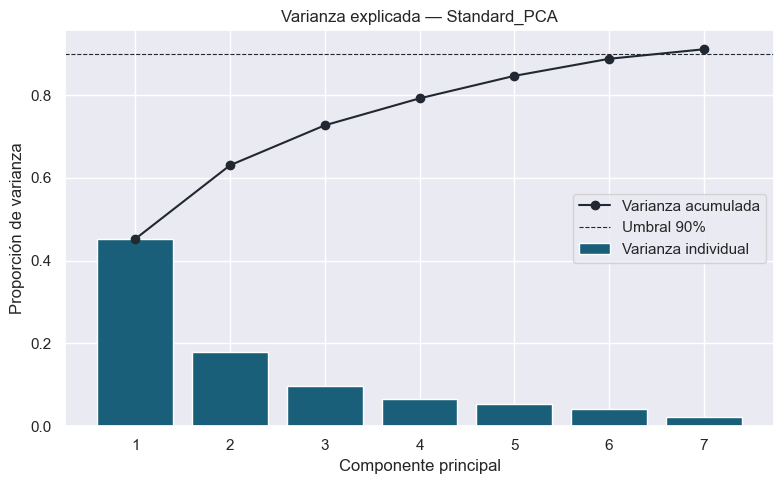

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
x = range(1, len(explained) + 1)

ax.bar(x, explained, color="#1A5F7A", label="Varianza individual")
ax.plot(x, cumulative, color="#222831", marker="o", label="Varianza acumulada")
ax.axhline(0.90, color="#222831", linestyle="--", linewidth=0.8, label="Umbral 90%")

ax.set(
    title="Varianza explicada — Standard_PCA",
    xlabel="Componente principal",
    ylabel="Proporción de varianza",
)

ax.legend()
plt.tight_layout()
plt.show()

In [44]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{
            "Model": "Standard_PCA",
            **evaluate_model(y_test, pipe_pca.predict(X_test))
        }]),
    ],
    ignore_index=True,
)

Recall: 0.9286
Precision: 1.0000
Accuracy: 0.9737


**Respuesta — Ejercicio 6:** Se emplearon **7 componentes principales**, suficientes para explicar al menos el 90% de la varianza del conjunto escalado.


## 7. Pipeline con transformación Yeo-Johnson

- Integra `preprocessing`, Yeo-Johnson y regresión logística.
- Entrena, evalúa y registra resultados como `Correlation_Yeo`.


In [45]:
from sklearn.preprocessing import PowerTransformer


In [46]:
pipe_yeo = Pipeline(
    [
        ("preprocessing", preprocessing),
        ("power", PowerTransformer(method="yeo-johnson")),
        ("logisticregression", LogisticRegression(max_iter=10_000)),
    ]
)

pipe_yeo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('power', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('drop', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [47]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "Correlation_Yeo", **evaluate_model(y_test, pipe_yeo.predict(X_test))}]),
    ],
    ignore_index=True,
)

Recall: 0.9524
Precision: 1.0000
Accuracy: 0.9825


In [48]:
metrics_melt = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

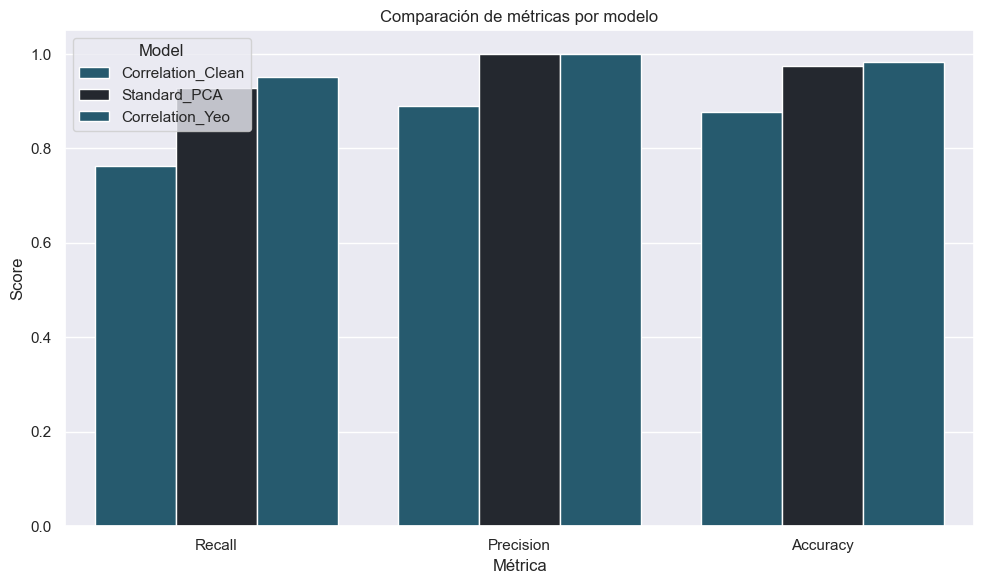

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=metrics_melt,
    x="Metric",
    y="Score",
    hue="Model",
    palette=PALETTE,
    ax=ax,
)

ax.set(
    title="Comparación de métricas por modelo",
    xlabel="Métrica",
    ylabel="Score",
)

ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 8. Coeficientes del modelo Yeo-Johnson

- Obtén los predictores empleados. ¿Cuántos son?
- Identifica las 10 variables más influyentes y grafícalas en un barplot horizontal.


In [50]:
features_kept = [col for col in X.columns if col not in COLS_TO_REMOVE]
print(f"Predictores empleados: {len(features_kept)}")
print(features_kept)

Predictores empleados: 16
['radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se']


In [51]:
coefs_df = pd.DataFrame(
    {
        "Feature": features_kept,
        "Coefficient": pipe_yeo.named_steps["logisticregression"].coef_[0],
    }
)

In [52]:
top_10 = coefs_df.assign(Abs=coefs_df["Coefficient"].abs()).nlargest(10, "Abs")

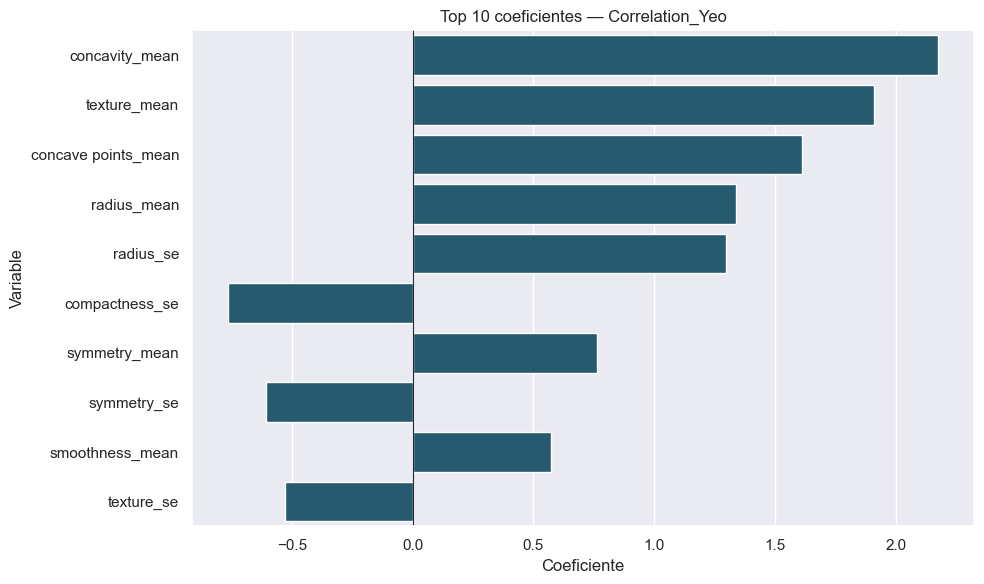

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_10, x="Coefficient", y="Feature", color="#1A5F7A", ax=ax)
ax.set(
    title="Top 10 coeficientes — Correlation_Yeo",
    xlabel="Coeficiente",
    ylabel="Variable",
)
ax.axvline(0, color="#222831", linewidth=0.8)
plt.tight_layout()
plt.show()

**Respuesta — Ejercicio 8:** Se emplearon **16 predictores** tras eliminar columnas `_worst` y las medidas redundantes de perímetro/área. Las variables más influyentes son `concavity_mean`, `texture_mean` y `concave points_mean`, con coeficientes positivos que incrementan la probabilidad de malignidad.


## 9. Comparación de modelos, matriz de confusión y curva ROC

- Imprime el dataframe de resultados.
- Dibuja la matriz de confusión del mejor modelo. ¿Qué significa cada valor?
- Dibuja la curva ROC y describe qué indica sobre la capacidad de discriminación.


In [54]:
display(results_df.round(4))

,Model,Recall,Precision,Accuracy
0,Correlation_Clean,0.7619,0.8889,0.8772
1,Standard_PCA,0.9286,1.0000,0.9737
2,Correlation_Yeo,0.9524,1.0000,0.9825


In [55]:
best_model = results_df.loc[results_df["Accuracy"].idxmax(), "Model"]
print(f"\nMejor modelo por exactitud: {best_model}")


Mejor modelo por exactitud: Correlation_Yeo


In [56]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, roc_curve

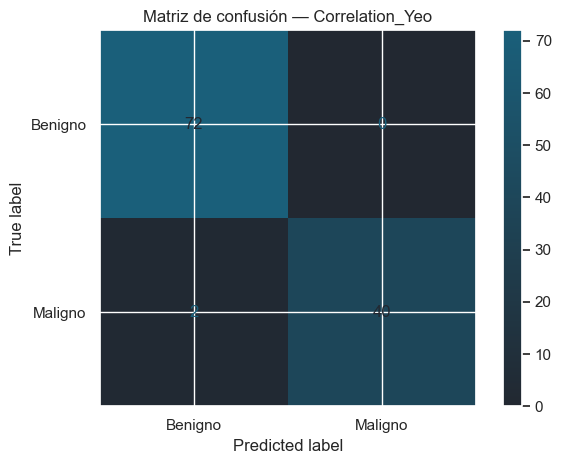

In [57]:
ConfusionMatrixDisplay.from_estimator(
    pipe_yeo,
    X_test,
    y_test,
    display_labels=["Benigno", "Maligno"],
    cmap=CUSTOM_CMAP,
)

plt.title("Matriz de confusión — Correlation_Yeo")
plt.tight_layout()
plt.show()


In [58]:
from sklearn.metrics import confusion_matrix

models = {
    "Correlation_Clean": pipe_clean,
    "Standard_PCA": pipe_pca,
    "Correlation_Yeo": pipe_yeo,
}

for name, model in models.items():
    cm = confusion_matrix(y_test, model.predict(X_test))
    print(f"\n{name}:")
    print(cm)


Correlation_Clean:
[[68  4]
 [10 32]]

Standard_PCA:
[[72  0]
 [ 3 39]]

Correlation_Yeo:
[[72  0]
 [ 2 40]]


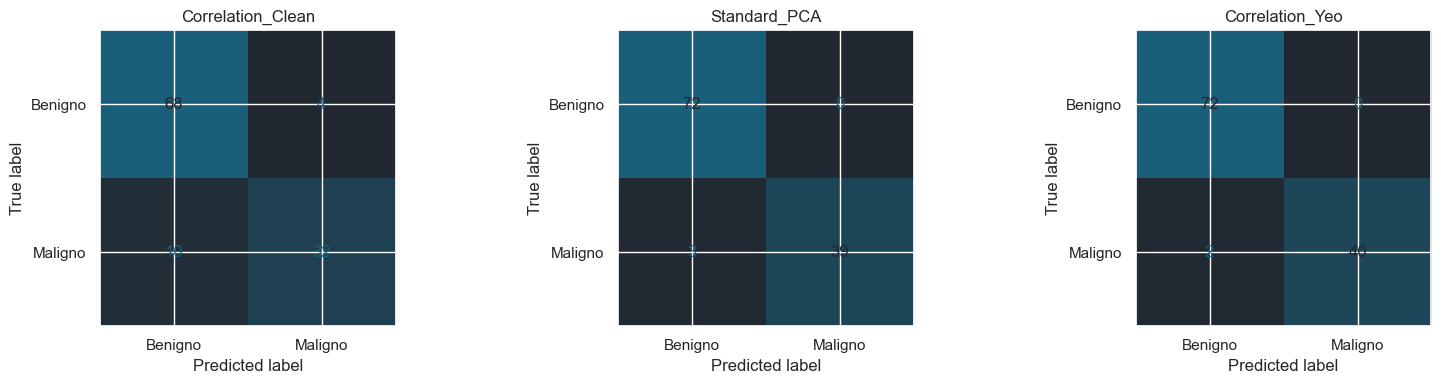

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=["Benigno", "Maligno"],
        cmap=CUSTOM_CMAP,
        ax=ax,
        colorbar=False,
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [60]:
y_proba = pipe_yeo.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

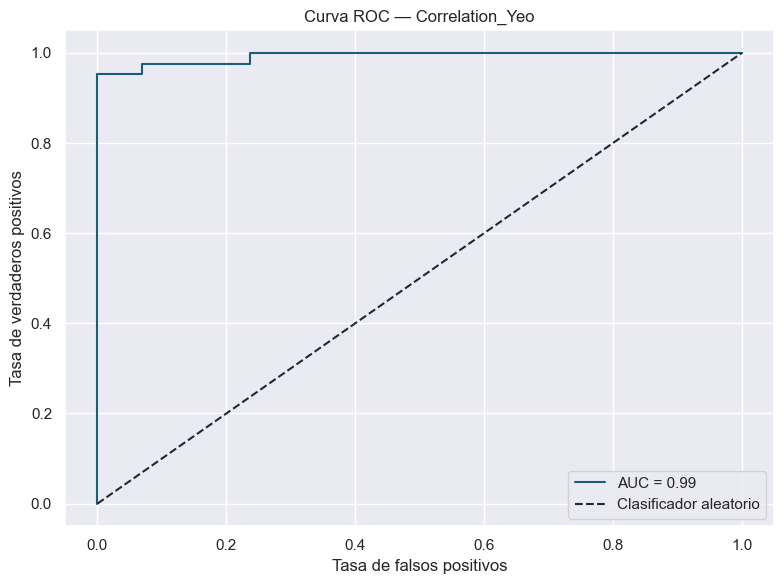

In [61]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#1A5F7A", label=f"AUC = {auc:.2f}")
ax.plot(
    [0, 1],
    [0, 1],
    color="#222831",
    linestyle="--",
    label="Clasificador aleatorio",
)

ax.set(
    title="Curva ROC — Correlation_Yeo",
    xlabel="Tasa de falsos positivos",
    ylabel="Tasa de verdaderos positivos",
)

ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [62]:
from sklearn.metrics import average_precision_score, precision_recall_curve

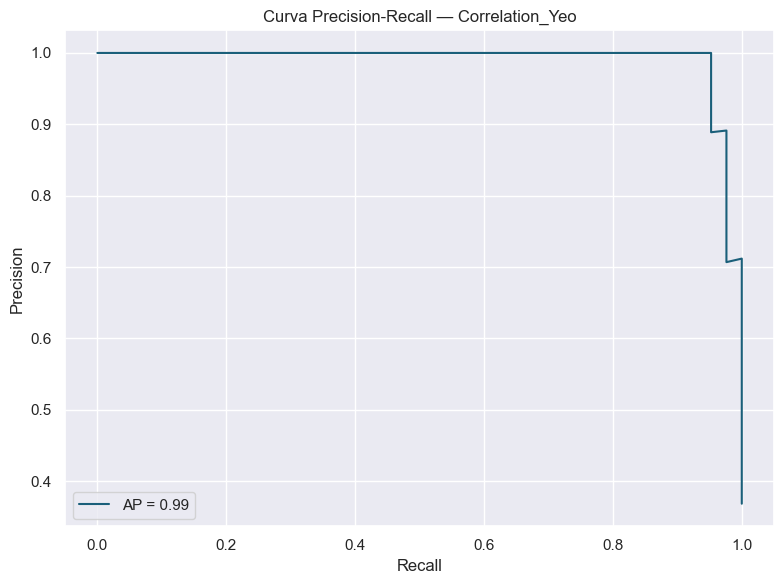

In [63]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color="#1A5F7A", label=f"AP = {avg_precision:.2f}")
ax.set(
    title="Curva Precision-Recall — Correlation_Yeo",
    xlabel="Recall",
    ylabel="Precision",
)

ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

**Respuestas — Ejercicio 9**

- **Mejor modelo:** `Correlation_Yeo` (Accuracy ≈ 0.98, Recall ≈ 0.95, Precision = 1.00).
- **Matriz de confusión** (filas = real, columnas = predicho):
  - **Verdaderos negativos (72):** tumores benignos correctamente clasificados.
  - **Falsos positivos (0):** benignos clasificados erróneamente como malignos.
  - **Falsos negativos (2):** malignos clasificados erróneamente como benignos.
  - **Verdaderos positivos (40):** tumores malignos correctamente detectados.
- **Curva ROC:** Con AUC ≈ 0.99, el modelo separa muy bien ambas clases a lo largo de distintos umbrales; está muy por encima del clasificador aleatorio.


## 10. Distribución de probabilidades predichas

- Grafica histogramas superpuestos de la probabilidad de clase Maligno (1), diferenciando la clase real.
- ¿Cuál es el umbral por defecto de scikit-learn?
- En diagnóstico médico, ¿cuál es la métrica más importante?
- ¿Cómo cambiarías el umbral? ¿Por qué?


In [64]:
probs_df = pd.DataFrame(
    {
        "True_Class": y_test.map({0: "Benigno (B)", 1: "Maligno (M)"}),
        "Prob_Maligno": y_proba,
    }
)

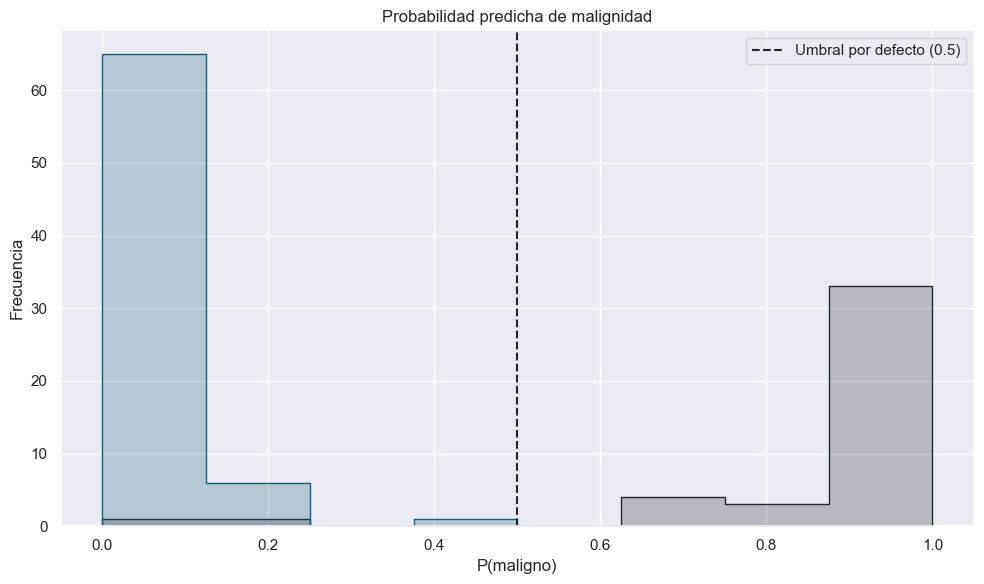

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=probs_df,
    x="Prob_Maligno",
    hue="True_Class",
    element="step",
    palette=PALETTE,
    ax=ax,
)

ax.axvline(
    0.5, color="#222831", linestyle="--", label="Umbral por defecto (0.5)"
)

ax.set(
    title="Probabilidad predicha de malignidad",
    xlabel="P(maligno)",
    ylabel="Frecuencia",
)

ax.legend()
plt.tight_layout()
plt.show()


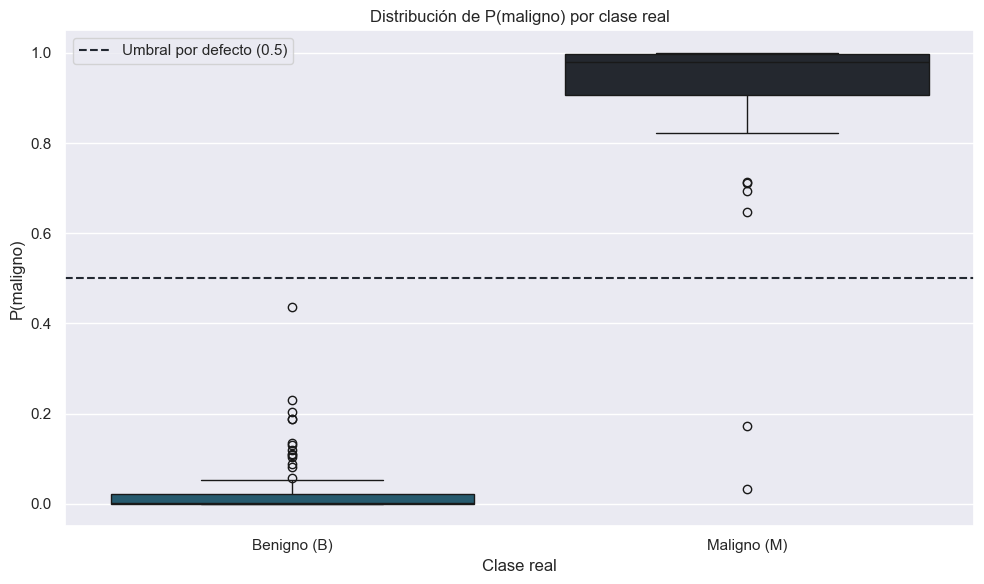

In [66]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=probs_df,
    x="True_Class",
    y="Prob_Maligno",
    hue="True_Class",
    palette=PALETTE,
    legend=False,
    ax=ax,
)

ax.axhline(0.5, color="#222831", linestyle="--", label="Umbral por defecto (0.5)")
ax.set(
    title="Distribución de P(maligno) por clase real",
    xlabel="Clase real",
    ylabel="P(maligno)",
)

ax.legend()
plt.tight_layout()
plt.show()

**Respuestas — Ejercicio 10**

- **Umbral por defecto:** scikit-learn usa **0.5**; si P(maligno) ≥ 0.5 predice clase 1, en caso contrario clase 0.
- **Métrica más importante en diagnóstico médico:** **Recall (sensibilidad)**, porque un falso negativo (no detectar un cáncer) tiene consecuencias clínicas graves. Es preferible tolerar más falsos positivos que omitir casos malignos.
- **Ajuste del umbral:** Se **disminuiría** el umbral (p. ej. de 0.5 a 0.3) para aumentar el recall y detectar más malignos, aceptando más falsos positivos que luego pueden descartarse con pruebas adicionales.
